<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/quebin_data_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01.DCGAN

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys

# 코랩의 경우 깃허브 저장소로부터 utils.py를 다운로드 합니다.
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks

--2026-05-07 16:31:25--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-05-07 16:31:25 (59.8 MB/s) - ‘utils.py’ saved [771/771]



In [6]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    losses,
    utils,
    metrics,
    optimizers,
)

from notebooks.utils import display, sample_batch

In [7]:
IMAGE_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 128
Z_DIM = 100
EPOCHS = 100 # 훈련이 오래 걸려 에포크 횟수를 300에서 100으로 줄입니다.
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
LEARNING_RATE = 0.0002
NOISE_PARAM = 0.1

In [8]:
# 코랩일 경우 노트북에서 celeba 데이터셋을 받습니다.
if 'google.colab' in sys.modules:
    # # 캐글-->Setttings-->API-->Create New Token에서
    # # kaggle.json 파일을 만들어 코랩에 업로드하세요.
    # from google.colab import files
    # files.upload()
    # !mkdir ~/.kaggle
    # !cp kaggle.json ~/.kaggle/
    # !chmod 600 ~/.kaggle/kaggle.json
    # 데이터셋을 다운로드하고 압축을 해제합니다.
    !kaggle datasets download -d joosthazelzet/lego-brick-images
    #
    # 캐글에서 다운로드가 안 될 경우 역자의 드라이브에서 다운로드할 수 있습니다.
    # import gdown
    # gdown.download(id='1qd50QDZtr_NYFiFVdp0sIvGDwTT3mMEQ')
    !unzip -q lego-brick-images.zip
    # output 디렉토리를 만듭니다.
    !mkdir output

Dataset URL: https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images
License(s): GPL-2.0
100% 1.00G/1.00G [01:03<00:00, 16.8MB/s]



In [9]:
train_data = utils.image_dataset_from_directory(
    "./dataset/",
    labels=None,
    color_mode="grayscale",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)

Found 40000 files.


In [10]:
def preprocess(img):
    """
    이미지 정규화 및 크기 변경
    """
    img = (tf.cast(img, "float32") - 127.5) / 127.5
    return img


train = train_data.map(lambda x: preprocess(x))

사용 장치: cuda
GPU 이름: Tesla T4
--------------------
Tensor Shape: torch.Size([32, 1, 64, 64])
Device: cuda:0
--------------------
Min: -1.0
Max: 0.2627451419830322


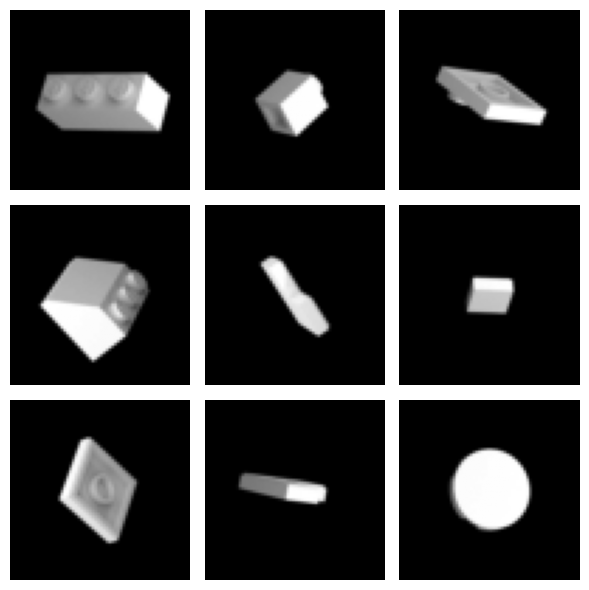

In [12]:
# PyTorch에서는 사용자 정의 Dataset 을 만들어야 합니다.
# 아래 코드는 TensorFlow 코드와 거의 동일하게 동작합니다.

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 장치:", device)

# GPU 이름 출력
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

# 설정값
IMAGE_SIZE = 64
BATCH_SIZE = 32

# Transform
# [0,255] -> [-1,1]
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                # [0,255] -> [0,1]
    transforms.Normalize((0.5,), (0.5,))  # [0,1] -> [-1,1]
])

# Custom Dataset
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(
                (".png", ".jpg", ".jpeg", ".bmp")
            )
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        return image

# Dataset 생성
train_dataset = CustomImageDataset(
    root_dir='./dataset/',
    transform=transform
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# sample_batch
def sample_batch(dataloader):
    images = next(iter(dataloader))

    # GPU 이동
    images = images.to(device)

    return images

# 샘플 추출
train_sample = sample_batch(train_loader)

print('-'*20)
print("Tensor Shape:", train_sample.shape)
print("Device:", train_sample.device)
print('-'*20)
print("Min:", train_sample.min().item())
print("Max:", train_sample.max().item())

# GPU -> CPU 변환 후 시각화
images_cpu = train_sample.cpu()
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images_cpu[i].squeeze().numpy()

    # [-1,1] -> [0,1]
    img = (img + 1) / 2

    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()